# Tech Challenge Fase 01 — EDA & ML Canvas

**Dataset:** Telco Customer Churn (IBM Watson Analytics)  
**Objetivo:** Prever cancelamento de clientes de telecomunicações (classificação binária)

## ML Canvas

| Campo | Descrição |
|-------|----------|
| **Problema de negócio** | Operadora perde clientes em ritmo acelerado. Precisa identificar quem vai cancelar para agir preventivamente. |
| **Stakeholders** | Diretoria comercial, equipe de retenção, produto |
| **Métrica de negócio** | Custo de churn evitado (R$/mês). FN custa ~10x mais que FP. |
| **Métrica técnica** | AUC-ROC ≥ 0.80, PR-AUC ≥ 0.60, F1 ≥ 0.60 |
| **SLOs** | Latência p99 < 200ms, disponibilidade > 99.5% |
| **Input** | Features do cliente: contrato, serviços, cobrança, tenure |
| **Output** | Probabilidade de churn [0,1] + classe binária |
| **Frequência** | Real-time via API |
| **Riscos** | Data drift por mudanças de produto, viés por gênero/idade |
| **Dados disponíveis** | 7.043 registros, 21 colunas, ~26% churn rate |

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_raw, get_features_target
from src.config import NUMERIC_FEATURES, CATEGORICAL_FEATURES, TARGET

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

## 1. Carregamento e Visão Geral

In [2]:
df = load_raw('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Qualidade dos Dados

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
result = pd.DataFrame({'missing': missing, 'pct': missing_pct}).query('missing > 0')
print(result if len(result) > 0 else 'Nenhum valor nulo encontrado.')

Nenhum valor nulo encontrado.


In [5]:
# TotalCharges tem espaços em branco que viram NaN após conversão numérica
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"TotalCharges NaN após conversão: {df['TotalCharges'].isnull().sum()}")
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']].head()

TotalCharges NaN após conversão: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN


## 3. Distribuição do Target

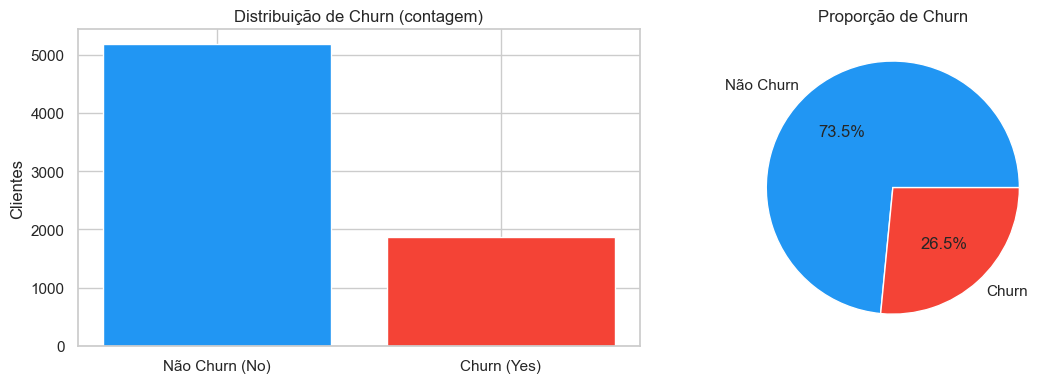

Churn rate: 26.5%


In [6]:
churn_counts = df[TARGET].value_counts()
churn_pct    = df[TARGET].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Não Churn (No)', 'Churn (Yes)'], churn_counts.values, color=['#2196F3', '#F44336'])
axes[0].set_title('Distribuição de Churn (contagem)')
axes[0].set_ylabel('Clientes')

axes[1].pie(churn_counts.values, labels=['Não Churn', 'Churn'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'])
axes[1].set_title('Proporção de Churn')
plt.tight_layout()
plt.show()
print(f"Churn rate: {churn_pct.get('Yes', 0):.1f}%")

## 4. Features Numéricas

In [7]:
df[NUMERIC_FEATURES].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


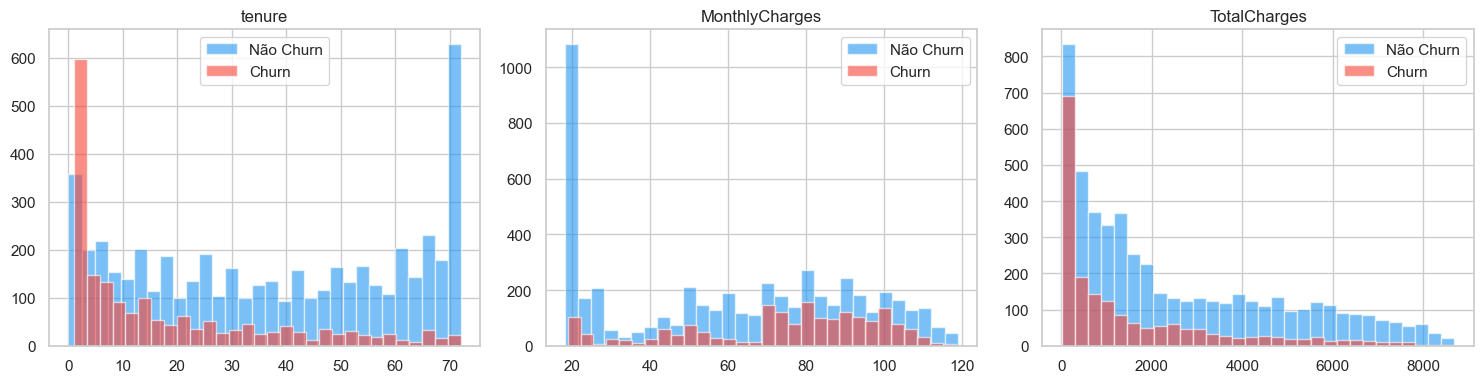

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, NUMERIC_FEATURES):
    df[df[TARGET] == 'No'][feat].dropna().hist(ax=ax, bins=30, alpha=0.6, label='Não Churn', color='#2196F3')
    df[df[TARGET] == 'Yes'][feat].dropna().hist(ax=ax, bins=30, alpha=0.6, label='Churn', color='#F44336')
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()
plt.show()

## 5. Features Categóricas vs Churn

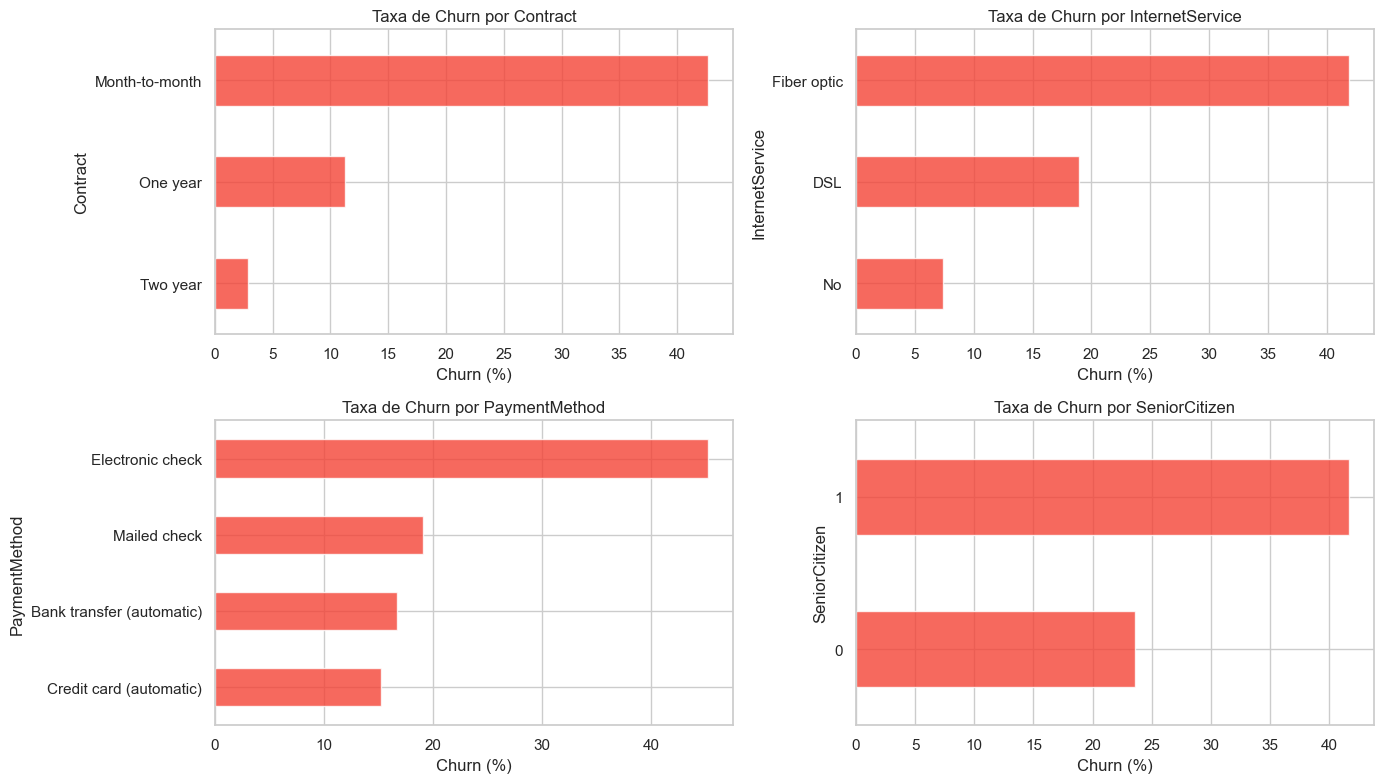

In [9]:
key_cats = ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, feat in zip(axes.flat, key_cats):
    ct = pd.crosstab(df[feat], df[TARGET], normalize='index') * 100
    ct['Yes'].sort_values().plot(kind='barh', ax=ax, color='#F44336', alpha=0.8)
    ax.set_title(f'Taxa de Churn por {feat}')
    ax.set_xlabel('Churn (%)')
plt.tight_layout()
plt.show()

## 6. Correlações

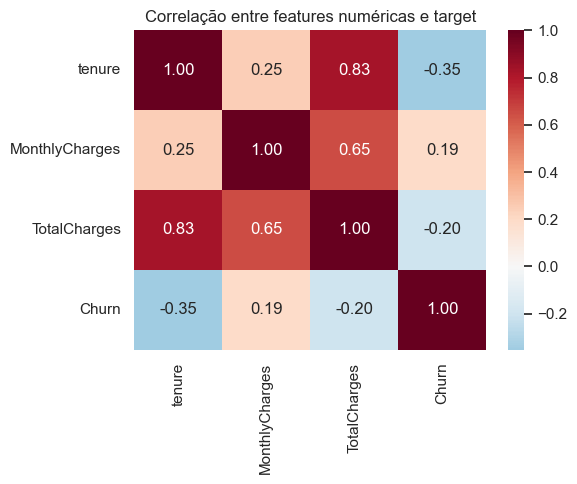

In [10]:
num_df = df[NUMERIC_FEATURES].copy()
num_df['Churn'] = (df[TARGET] == 'Yes').astype(int)

corr = num_df.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlação entre features numéricas e target')
plt.tight_layout()
plt.show()

## 7. Data Readiness

| Critério | Status |
|----------|--------|
| Volume (≥5.000 registros) | ✅ 7.043 registros |
| Features (≥10) | ✅ 19 features utilizadas |
| Missing values | ✅ Apenas 11 linhas em TotalCharges (0.15%) — imputável |
| Target definido | ✅ `Churn` binário (Yes/No → 1/0) |
| Desbalanceamento | ⚠️ ~26% churn — moderado, monitorar PR-AUC |
| Leakage | ✅ Apenas customerID removido (sem colunas derivadas do churn) |
| Reprodutibilidade | ✅ Seed=42, split estratificado |